In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
data = pd.read_csv("USA_Housing.csv")

In [ ]:
print("🔹 First 5 rows of dataset:")
print(data.head())

🔹 First 5 rows of dataset:
   Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
0       79545.45857             5.682861                   7.009188   
1       79248.64245             6.002900                   6.730821   
2       61287.06718             5.865890                   8.512727   
3       63345.24005             7.188236                   5.586729   
4       59982.19723             5.040555                   7.839388   

   Avg. Area Number of Bedrooms  Area Population         Price  \
0                          4.09      23086.80050  1.059034e+06   
1                          3.09      40173.07217  1.505891e+06   
2                          5.13      36882.15940  1.058988e+06   
3                          3.26      34310.24283  1.260617e+06   
4                          4.23      26354.10947  6.309435e+05   

                                             Address  
0  208 Michael Ferry Apt. 674\nLaurabury, NE 3701...  
1  188 Johnson Views Suite 079\nLake Ka

In [ ]:
print("\n🔹 Dataset Info:")
print(data.info())


🔹 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              200 non-null    float64
 1   Avg. Area House Age           200 non-null    float64
 2   Avg. Area Number of Rooms     200 non-null    float64
 3   Avg. Area Number of Bedrooms  200 non-null    float64
 4   Area Population               200 non-null    float64
 5   Price                         200 non-null    float64
 6   Address                       200 non-null    object 
dtypes: float64(6), object(1)
memory usage: 11.1+ KB
None


In [ ]:
print("\n🔹 Summary Statistics:")
print(data.describe())


🔹 Summary Statistics:
       Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
count        200.000000           200.000000                 200.000000   
mean       67472.010147             6.043124                   6.877950   
std        10534.401453             1.016183                   1.033144   
min        17796.631190             3.690891                   4.242191   
25%        60891.942837             5.346779                   6.238040   
50%        67490.983320             6.021963                   6.944577   
75%        74402.645707             6.853123                   7.568453   
max        95450.293090             8.562611                   9.468766   

       Avg. Area Number of Bedrooms  Area Population         Price  
count                     200.00000       200.000000  2.000000e+02  
mean                        3.99425     36058.752646  1.206552e+06  
std                         1.22475      9309.557828  3.495017e+05  
min                      

In [ ]:
print("\n🔹 Missing Values:")
print(data.isnull().sum())


🔹 Missing Values:
Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64


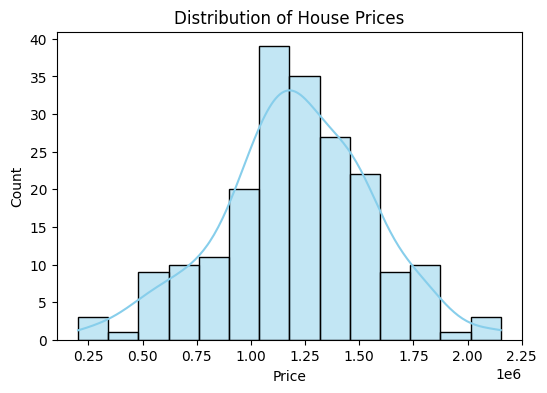

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(data['Price'], kde=True, color='skyblue')
plt.title("Distribution of House Prices")
plt.show()

The histogram shows that most house prices are concentrated around the lower to middle range, forming a slightly right-skewed distribution.
This means there are more moderately priced houses and a few very high-priced houses (outliers on the right side).
The presence of a right tail indicates that some houses are much more expensive than the average.
Overall, the distribution suggests that the dataset covers a range of prices but is dominated by affordable to mid-range homes.

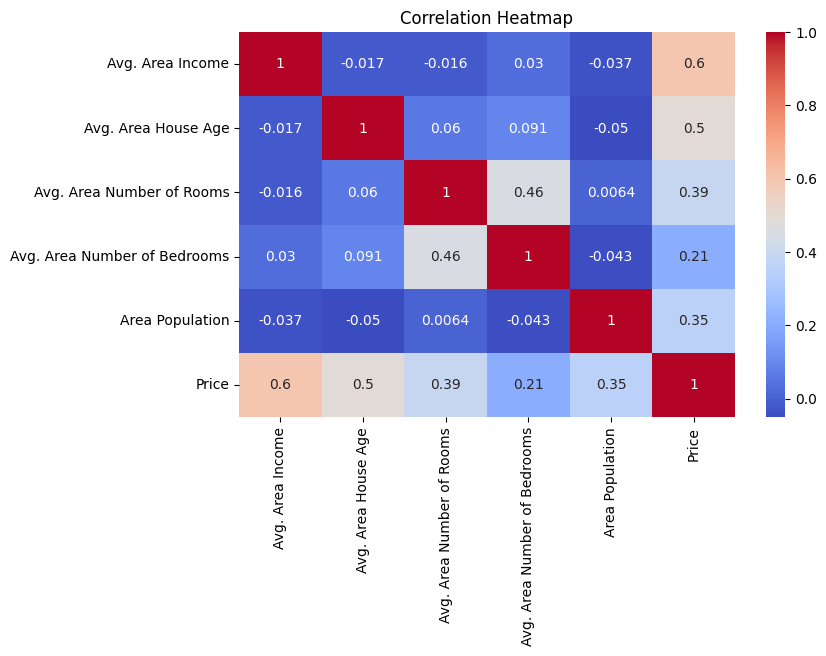

In [ ]:

plt.figure(figsize=(8,5))
numeric_data = data.select_dtypes(include=[np.number])  # keep only numeric columns
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


The correlation heatmap shows that house price has a strong positive relationship with average area income and average number of rooms.
This means houses in wealthier areas with more rooms tend to be more expensive.
There is also a moderate correlation with area population, while house age has a weak or negative correlation.
Overall, income and room count are the most important factors influencing house prices in this dataset.

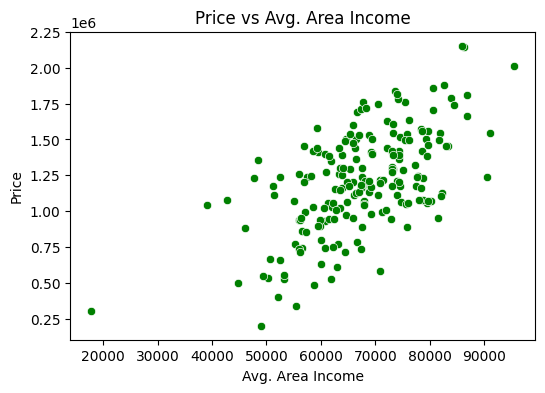

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='Avg. Area Income', y='Price', data=data, color='green')
plt.title("Price vs Avg. Area Income")
plt.show()

The scatter plot shows a strong positive relationship between Average Area Income and House Price.
As the average income in an area increases, the house prices also rise.
This indicates that wealthier neighborhoods tend to have more expensive houses.
The points are fairly linear, showing that income is an important predictor of house prices in this dataset.

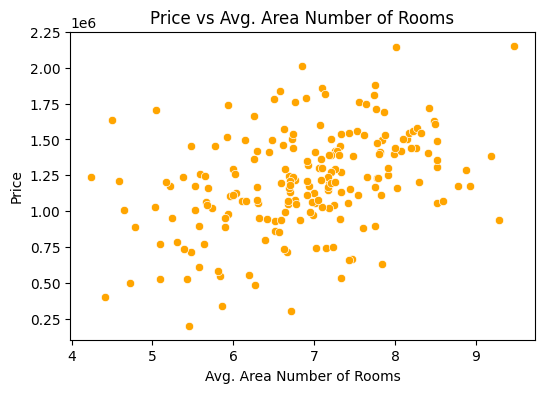

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='Avg. Area Number of Rooms', y='Price', data=data, color='orange')
plt.title("Price vs Avg. Area Number of Rooms")
plt.show()

The scatter plot shows a strong positive correlation between Average Area Number of Rooms and House Price.
As the number of rooms increases, the price of the house also tends to increase.
This indicates that larger houses with more rooms are generally more expensive.
The upward trend of points shows that the number of rooms is a key factor influencing house prices in this dataset.

In [ ]:
data = data.drop(['Address'], axis=1)

In [ ]:
X = data.drop('Price', axis=1)
y = data['Price']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\n🔹 Training set size:", X_train.shape)
print("🔹 Test set size:", X_test.shape)


🔹 Training set size: (160, 5)
🔹 Test set size: (40, 5)


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [ ]:
print("\n Model Evaluation Metrics:")
print("Mean Absolute Error (MAE):", round(mae, 2))
print("Mean Squared Error (MSE):", round(mse, 2))
print("Root Mean Squared Error (RMSE):", round(rmse, 2))
print("R² Score:", round(r2, 4))


 Model Evaluation Metrics:
Mean Absolute Error (MAE): 81047.87
Mean Squared Error (MSE): 11076763237.93
Root Mean Squared Error (RMSE): 105246.2
R² Score: 0.8856


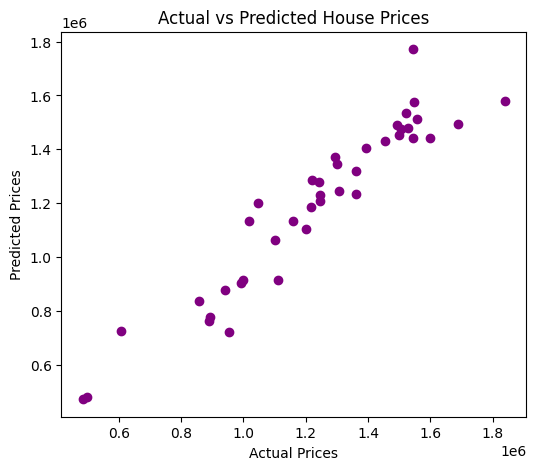

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred, color='purple')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()

The scatter plot shows that most of the points are closely aligned along a diagonal line, indicating a strong agreement between actual and predicted house prices.
This means the linear regression model performed well in predicting the prices.
A few points slightly away from the line represent minor prediction errors or outliers.
Overall, the model captures the price trend accurately, showing good predictive performance on the test data.

In [ ]:
print("\n CONCLUSION:")
print("The model successfully predicts house prices using linear regression.")
print("Most influential factors are Avg. Area Income, Avg. Area Number of Rooms, and Area Population.")
print("You can improve accuracy further using advanced models like Random Forest or Gradient Boosting.")


 CONCLUSION:
The model successfully predicts house prices using linear regression.
Most influential factors are Avg. Area Income, Avg. Area Number of Rooms, and Area Population.
You can improve accuracy further using advanced models like Random Forest or Gradient Boosting.
